In [19]:
pip install transformers torch torchvision pillow requests

Note: you may need to restart the kernel to use updated packages.


In [20]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt

from transformers import ViTImageProcessor
from transformers import ViTForImageClassification

In [21]:
import torch

print(torch.__version__)

2.13.0+cpu


In [22]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224"
)

print("Model Loaded")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model Loaded


In [23]:
import requests

url = "https://huggingface.co"

response = requests.get(url)

print(response.status_code)

200


In [24]:
import os
print(os.getcwd())

C:\Users\dhana


In [25]:
import os
print(os.getcwd())

C:\Users\dhana


In [26]:
import os
print(os.getcwd())

C:\Users\dhana


In [27]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\dhana
['.anaconda', '.cache', '.cagent', '.conda', '.condarc', '.config', '.continuum', '.dbt', '.docker', '.duckdb_history', '.eclipse', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.m2', '.matplotlib', '.ms-ad', '.node_repl_history', '.ollama', '.p2', '.redhat', '.vscode', '.vscode-shared', 'AirPassengers timeseries.pdf', 'AirPassengers.csv', 'anaconda3', 'ansel', 'AppData', 'Application Data', 'car_buy.csv', 'car_buy_model.pkl', 'Contacts', 'Cookies', 'decision tree.ipynb', 'decision_tree_car_model-Copy1.pkl', 'decision_tree_car_model.pkl', 'DEEP LEARN', 'Deep learn t-2.ipynb', 'DL TASK 1[].ipynb', 'DL Task 3.ipynb', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'ex12.ipynb', 'exp 11 Hierarchical Clustering .ipynb', 'exp 15.ipynb', 'exp 16 .ipynb', 'exp 18.ipynb', 'exp 19.ipynb', 'exp 7 random forest.ipynb', 'exp 8 svm.ipynb', 'exp 9 nc.ipynb', 'exp10.ipynb', 'exp8.module4 IoT.ipynb', 'Favorites', 'GEN AI', 'Gen Ai task 1.ipynb'

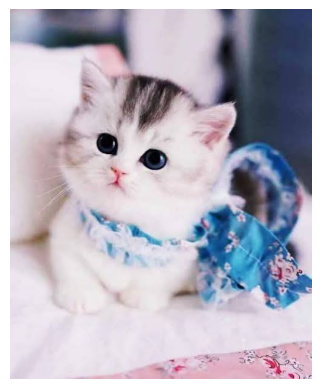

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("cat.jpeg")

plt.imshow(image)
plt.axis("off")
plt.show()

In [7]:
from transformers import ViTImageProcessor, ViTForImageClassification

# Load pretrained ViT model and processor
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

print("Model loaded successfully")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model loaded successfully


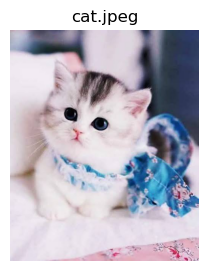

Image: cat.jpeg
Predicted Class: Egyptian cat
Confidence Score: 21.73 %
---------------------------


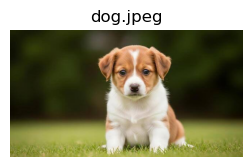

Image: dog.jpeg
Predicted Class: Cardigan, Cardigan Welsh corgi
Confidence Score: 17.68 %
---------------------------


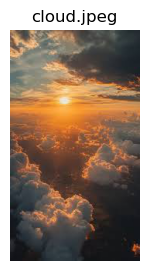

Image: cloud.jpeg
Predicted Class: wing
Confidence Score: 93.5 %
---------------------------


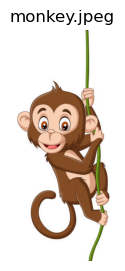

Image: monkey.jpeg
Predicted Class: swing
Confidence Score: 8.03 %
---------------------------


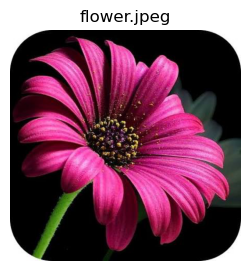

Image: flower.jpeg
Predicted Class: daisy
Confidence Score: 88.43 %
---------------------------


In [8]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

# List of image names
image_files = [
    "cat.jpeg",
    "dog.jpeg",
    "cloud.jpeg",
    "monkey.jpeg",
    "flower.jpeg"
]

# Predict each image
for img_name in image_files:
    
    # Load image
    image = Image.open(img_name).convert("RGB")
    
    # Display image
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis("off")
    plt.title(img_name)
    plt.show()
    
    # Process image
    inputs = processor(images=image, return_tensors="pt")
    
    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get class and confidence
    predicted_class = outputs.logits.argmax(-1).item()
    label = model.config.id2label[predicted_class]
    
    confidence = torch.nn.functional.softmax(
        outputs.logits, dim=1
    )[0][predicted_class].item()
    
    print("Image:", img_name)
    print("Predicted Class:", label)
    print("Confidence Score:", round(confidence*100,2), "%")
    print("---------------------------")